# Détection d’objets en temps réel avec YOLOv11

Objectif :
- Comprendre le pipeline complet de détection d’objets
- Utiliser PyTorch et YOLOv11
- Entraîner, évaluer et analyser un modèle de détection

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


### Import des librairies

In [ ]:
import os
import cv2
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm

In [ ]:
# ✅ DÉFINITION DES CHEMINS DU DATASET
from pathlib import Path

# Dataset brut
RAW_DATASET = Path("RAW_DATASET")

# Dataset nettoyé
CLEAN_DATASET = Path("dataset_clean")

print("RAW existe :", RAW_DATASET.exists())
print("CLEAN existe :", CLEAN_DATASET.exists())

if RAW_DATASET.exists():
    print("📂 RAW path :", RAW_DATASET.resolve())

if CLEAN_DATASET.exists():
    print("📂 CLEAN path :", CLEAN_DATASET.resolve())


RAW existe : True
CLEAN existe : True
📂 RAW path : C:\Users\asus\Desktop\ProjetPFE2\RAW_DATASET
📂 CLEAN path : C:\Users\asus\Desktop\ProjetPFE2\dataset_clean


### Charger la dataset dans le notebook (chemins dynamiques)

In [ ]:
import os
import yaml

# Charger data.yaml depuis le dataset RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

train_path = (RAW_DATASET / data_cfg["train"]).resolve()
val_path   = (RAW_DATASET / data_cfg["val"]).resolve()
test_path  = (RAW_DATASET / data_cfg["test"]).resolve()

print("Train images :", len(os.listdir(train_path)))
print("Valid images :", len(os.listdir(val_path)))
print("Test images  :", len(os.listdir(test_path)))


Train images : 6944
Valid images : 1000
Test images  : 2000


##  3.Explore the Dataset

### 3.1 Inspect Image Properties

image resolution

In [ ]:
from PIL import Image
import pandas as pd
import os
import yaml

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

IMG_DIR = (RAW_DATASET / data_cfg["train"]).resolve()

data = []

for img_name in os.listdir(IMG_DIR)[:30]:  # limite volontaire
    img_path = IMG_DIR / img_name
    with Image.open(img_path) as img:
        w, h = img.size
        data.append([img_name, w, h, img.mode, img.format])

df = pd.DataFrame(
    data,
    columns=["image", "width", "height", "color_mode", "format"]
)

df


,image,width,height,color_mode,format
0,b1c81faa-3df17267_jpg.rf.65881dccbdda40542e6d5...,1280,720,RGB,JPEG
1,b1c9c847-3bda4659_jpg.rf.f85d1e0ecfdaa631bf8e6...,1280,720,RGB,JPEG
2,b1ca8418-84a133a0_jpg.rf.5c98553bfe2aeee22f82b...,1280,720,RGB,JPEG
3,b1cac6a7-04e33135_jpg.rf.d89fb39a2d04089b30a7a...,1280,720,RGB,JPEG
4,b1cd1e94-26dd524f_jpg.rf.f7ff411855c3026e020a2...,1280,720,RGB,JPEG
5,b1cd1e94-549d0bfe_jpg.rf.e97fe17f8c66d523ef00d...,1280,720,RGB,JPEG
6,b1ceb32e-3f481b43_jpg.rf.907109b703a5fa9b0ed1c...,1280,720,RGB,JPEG
7,b1ceb32e-813f84b2_jpg.rf.11605842fd04c7f0cbbbb...,1280,720,RGB,JPEG
8,b1ceb32e-a106591d_jpg.rf.d6590b6d3997375064663...,1280,720,RGB,JPEG
9,b1cebfb7-284f5117_jpg.rf.f007896cfc9ce6174ea1a...,1280,720,RGB,JPEG


Aspect ratio distribution

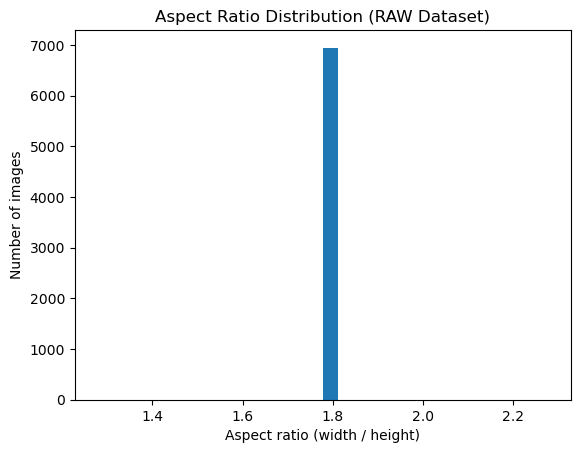

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import yaml

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

IMG_DIR = (RAW_DATASET / data_cfg["train"]).resolve()

ratios = []

for img_name in os.listdir(IMG_DIR):
    img_path = IMG_DIR / img_name
    with Image.open(img_path) as img:
        w, h = img.size
        ratios.append(w / h)

plt.hist(ratios, bins=30)
plt.xlabel("Aspect ratio (width / height)")
plt.ylabel("Number of images")
plt.title("Aspect Ratio Distribution (RAW Dataset)")
plt.show()


Color format (RGB / Grayscale)

In [ ]:
from PIL import Image
from collections import Counter
import yaml
import os

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

IMG_DIR = (RAW_DATASET / data_cfg["train"]).resolve()

color_modes = []

for img_name in os.listdir(IMG_DIR):
    img_path = IMG_DIR / img_name
    with Image.open(img_path) as img:
        color_modes.append(img.mode)

Counter(color_modes)


Counter({'RGB': 6944})

File formats (JPG, PNG, etc.)

In [ ]:
from collections import Counter
import os
import yaml

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

IMG_DIR = (RAW_DATASET / data_cfg["train"]).resolve()

formats = []

for img_name in os.listdir(IMG_DIR):
    ext = os.path.splitext(img_name)[1].lower()
    formats.append(ext)

Counter(formats)


Counter({'.jpg': 6944})

### 3.2 Inspect Annotations

Number of classes

In [ ]:
import os
import yaml
import matplotlib.pyplot as plt

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"
id_to_name = data_cfg["names"]

classes = set()

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        for line in f:
            cls = int(line.split()[0])
            classes.add(cls)

print("Nombre de classes :", len(classes))
print("Classes IDs :", sorted(classes))

print("\nClasses (ID → Nom) :")
for cls_id in sorted(classes):
    print(f"{cls_id} → {id_to_name[cls_id]}")



Nombre de classes : 13
Classes IDs : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Classes (ID → Nom) :
0 → bicycle
1 → bus
2 → car
3 → motorcycle
4 → other person
5 → other vehicle
6 → pedestrian
7 → rider
8 → traffic light
9 → traffic sign
10 → trailer
11 → train
12 → truck


Number of images per class

car                  : 6863 images
traffic sign         : 5719 images
traffic light        : 3913 images
pedestrian           : 2270 images
truck                : 1901 images
bus                  :  909 images
bicycle              :  410 images
rider                :  373 images
motorcycle           :  245 images
other vehicle        :   45 images
train                :    9 images
trailer              :    1 images
other person         :    1 images


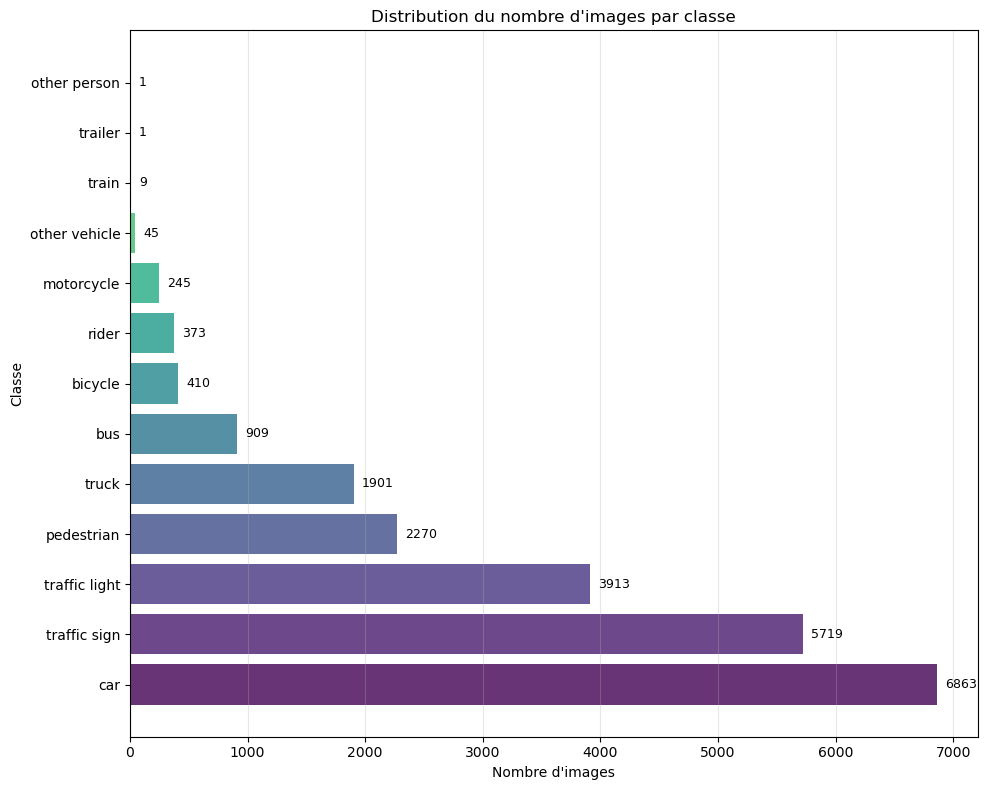

In [ ]:
import os
import yaml
from collections import defaultdict
import matplotlib.pyplot as plt

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"
id_to_name = data_cfg["names"]

# Compter le nombre d'images par classe
images_per_class = defaultdict(set)

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_name = id_to_name[cls_id]
            images_per_class[class_name].add(file)

images_per_class = {k: len(v) for k, v in images_per_class.items()}

# Afficher les données
for class_name, count in sorted(images_per_class.items(), key=lambda x: x[1], reverse=True):
    print(f"{class_name:20s} : {count:4d} images")

# 📊 VISUALISATION : Bar plot horizontal trié
plt.figure(figsize=(10, 8))
sorted_classes = sorted(images_per_class.items(), key=lambda x: x[1], reverse=True)
class_names = [x[0] for x in sorted_classes]
counts = [x[1] for x in sorted_classes]

colors = plt.cm.viridis([i/len(counts) for i in range(len(counts))])
plt.barh(class_names, counts, color=colors, alpha=0.8)
plt.xlabel("Nombre d'images")
plt.ylabel("Classe")
plt.title("Distribution du nombre d'images par classe")
plt.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (name, count) in enumerate(zip(class_names, counts)):
    plt.text(count + max(counts)*0.01, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()




Number of bounding boxes per image

In [ ]:
import pandas as pd
import os
import yaml
from pathlib import Path

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"

bbox_per_image = []

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        count = len(f.readlines())
        bbox_per_image.append(count)

bbox_stats = pd.Series(bbox_per_image)
bbox_stats.describe()


count    6944.000000
mean       18.657546
std         9.538899
min         1.000000
25%        11.000000
50%        18.000000
75%        24.000000
max        66.000000
dtype: float64

Distribution of object sizes (small / medium / large)

📊 Statistiques des tailles d'objets (aire normalisée):
count    129558.000000
mean          0.006985
std           0.023580
min           0.000000
25%           0.000324
50%           0.000851
75%           0.003111
max           0.622485
dtype: float64

🔍 Objets très petits (< 0.005) : 105162 (81.17%)
📦 Objets moyens (0.005 - 0.1)  : 22484 (17.35%)
📦 Objets larges (> 0.1)        : 1912 (1.48%)


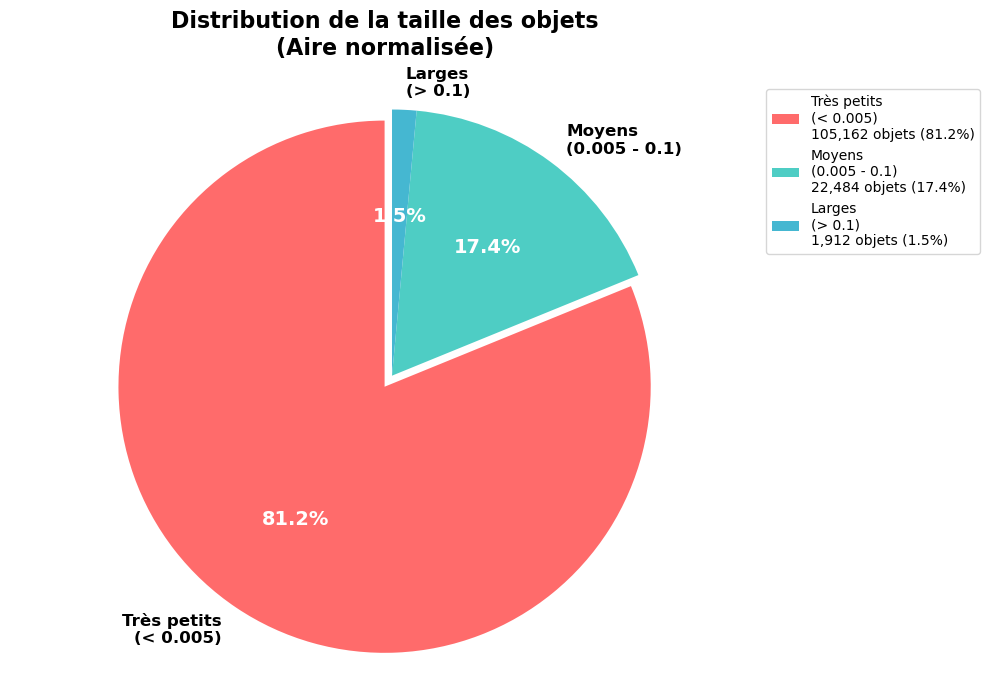

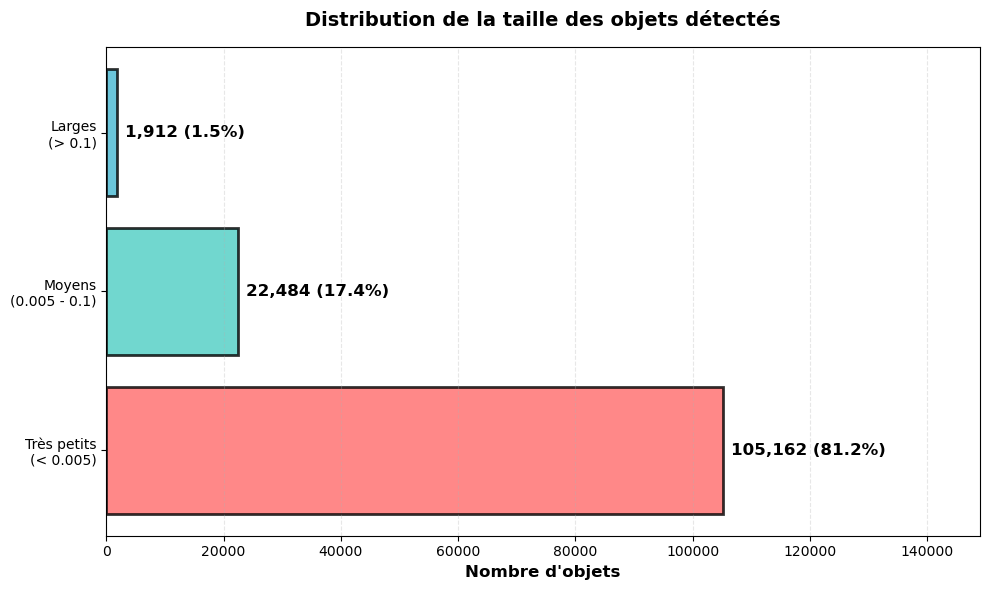

In [ ]:
import pandas as pd
import os
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"

sizes = []

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                _, _, _, w, h = map(float, parts)
                sizes.append(w * h)

sizes = pd.Series(sizes)

# Catégorisation
very_small = (sizes < 0.005).sum()
medium = ((sizes >= 0.005) & (sizes < 0.1)).sum()
large = (sizes >= 0.1).sum()
total = len(sizes)

# Statistiques
print("📊 Statistiques des tailles d'objets (aire normalisée):")
print(sizes.describe())
print(f"\n🔍 Objets très petits (< 0.005) : {very_small} ({very_small/total*100:.2f}%)")
print(f"📦 Objets moyens (0.005 - 0.1)  : {medium} ({medium/total*100:.2f}%)")
print(f"📦 Objets larges (> 0.1)        : {large} ({large/total*100:.2f}%)")

# ========================================
# 📊 VISUALISATION SIMPLE : Pie Chart
# ========================================
plt.figure(figsize=(10, 7))

categories = ['Très petits\n(< 0.005)', 'Moyens\n(0.005 - 0.1)', 'Larges\n(> 0.1)']
counts = [very_small, medium, large]
percentages = [very_small/total*100, medium/total*100, large/total*100]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

# Créer le pie chart
wedges, texts, autotexts = plt.pie(
    counts,
    labels=categories,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0.05, 0, 0),  # Faire ressortir la catégorie dominante
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Améliorer le style
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

plt.title('Distribution de la taille des objets\n(Aire normalisée)',
          fontsize=16, fontweight='bold', pad=20)

# Ajouter une légende avec les valeurs exactes
legend_labels = [
    f'{cat}\n{count:,} objets ({pct:.1f}%)'
    for cat, count, pct in zip(categories, counts, percentages)
]
plt.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.axis('equal')
plt.tight_layout()
plt.show()

# ========================================
# 📊 VISUALISATION ALTERNATIVE : Bar Chart Horizontal
# ========================================
plt.figure(figsize=(10, 6))

bars = plt.barh(categories, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Ajouter les valeurs et pourcentages sur les barres
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    plt.text(count + total*0.01, i,
             f'{count:,} ({pct:.1f}%)',
             va='center', fontsize=12, fontweight='bold')

plt.xlabel('Nombre d\'objets', fontsize=12, fontweight='bold')
plt.title('Distribution de la taille des objets détectés',
          fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, total * 1.15)

plt.tight_layout()
plt.show()

### 3.3 Identify Dataset Issues

3.1 desequilbre de classe

📊 Nombre d'instances (bounding boxes) par classe:
car                  : 71876 instances
traffic sign         : 24180 instances
traffic light        : 18426 instances
pedestrian           :  9374 instances
truck                :  2961 instances
bus                  :  1166 instances
bicycle              :   741 instances
rider                :   450 instances
motorcycle           :   325 instances
other vehicle        :    47 instances
train                :    10 instances
trailer              :     1 instances
other person         :     1 instances

📈 Rapport max/min : 71876.00x


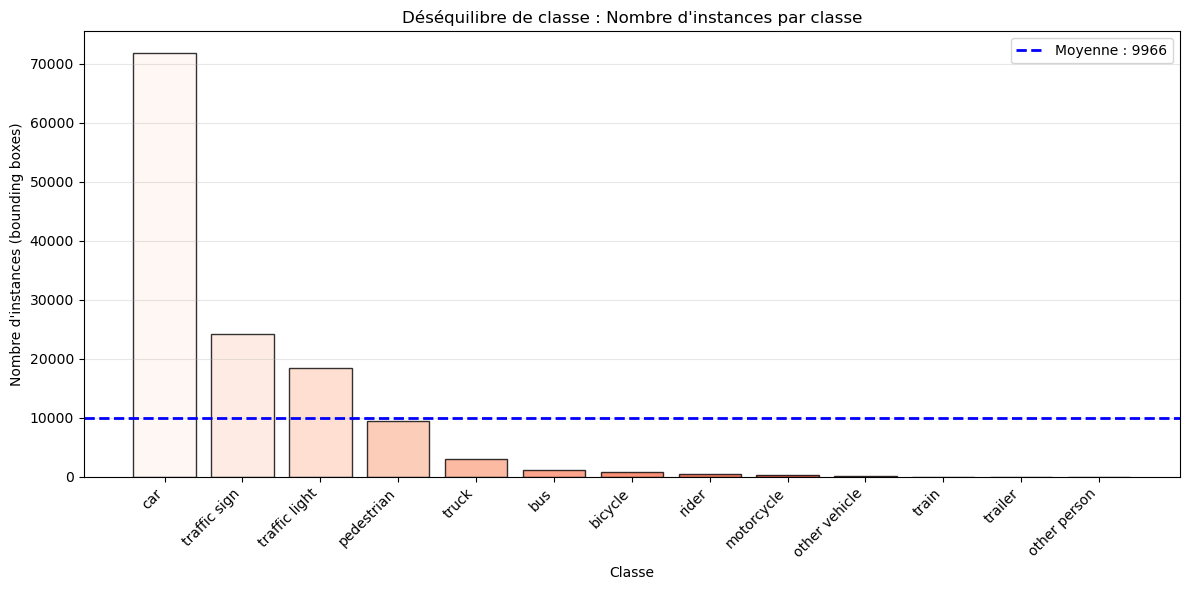

In [ ]:
import os
import yaml
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

# Charger config RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg["names"]
LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"

class_counts = Counter()

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_name = names[cls_id]
            class_counts[class_name] += 1

# Afficher les statistiques
print("📊 Nombre d'instances (bounding boxes) par classe:")
for class_name, count in class_counts.most_common():
    print(f"{class_name:20s} : {count:5d} instances")

print(f"\n📈 Rapport max/min : {max(class_counts.values()) / min(class_counts.values()):.2f}x")

# 📊 VISUALISATION 1 : Bar plot trié
plt.figure(figsize=(12, 6))
sorted_counts = class_counts.most_common()
class_names = [x[0] for x in sorted_counts]
counts = [x[1] for x in sorted_counts]

colors = plt.cm.Reds([i/len(counts) for i in range(len(counts))])
bars = plt.bar(range(len(class_names)), counts, color=colors, alpha=0.8, edgecolor='black')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.xlabel("Classe")
plt.ylabel("Nombre d'instances (bounding boxes)")
plt.title("Déséquilibre de classe : Nombre d'instances par classe")
plt.grid(axis='y', alpha=0.3)

# Ajouter ligne moyenne
mean_count = sum(counts) / len(counts)
plt.axhline(mean_count, color='blue', linestyle='--', linewidth=2, label=f'Moyenne : {mean_count:.0f}')
plt.legend()

plt.tight_layout()
plt.show()



Incorrect / inconsistent labels

In [ ]:
INVALID = []

LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"

for file in os.listdir(LABEL_DIR):
    with open(LABEL_DIR / file) as f:
        for i, line in enumerate(f):
            parts = line.split()

            # Mauvais format (pas 5 valeurs)
            if len(parts) != 5:
                INVALID.append((file, i))
                continue

            _, x, y, w, h = map(float, parts)

            # Coordonnées hors intervalle YOLO
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                INVALID.append((file, i))

len(INVALID)


926

Missing annotations (image sans label)

In [ ]:
# Dossiers RAW
IMG_DIR = (RAW_DATASET / data_cfg["train"]).resolve()
LABEL_DIR = (RAW_DATASET / data_cfg["train"]).parent / "labels"

images = {os.path.splitext(f)[0] for f in os.listdir(IMG_DIR)}
labels = {os.path.splitext(f)[0] for f in os.listdir(LABEL_DIR)}

missing_labels = images - labels

len(missing_labels)


0

In [ ]:
import os
import pandas as pd

LABEL_DIR = "RAW_DATASET/train/labels"

sizes_raw = []

for file in os.listdir(LABEL_DIR):
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                _, _, _, w, h = map(float, parts)
                sizes_raw.append(w * h)

sizes_raw = pd.Series(sizes_raw)


Extremely small objects

In [ ]:
# tailles déjà calculées dans sizes_raw
very_small_raw = sizes_raw[sizes_raw < 0.005]

len(very_small_raw)


105162

### partie nettoyage

Supprimer les labels incorrects / inconsistants

In [ ]:
import os
from pathlib import Path

RAW_LABEL_DIR = Path("RAW_DATASET/train/labels")
CLEAN_LABEL_DIR = Path("dataset_clean/train/labels")

CLEAN_LABEL_DIR.mkdir(parents=True, exist_ok=True)

invalid_count = 0

for file in RAW_LABEL_DIR.glob("*.txt"):

    valid_lines = []

    with open(file, "r") as f:
        for line in f:
            parts = line.split()

            if len(parts) != 5:
                invalid_count += 1
                continue

            cls, x, y, w, h = map(float, parts)

            if (
                0 <= x <= 1 and
                0 <= y <= 1 and
                0 < w <= 1 and
                0 < h <= 1
            ):
                valid_lines.append(line)
            else:
                invalid_count += 1

    # Sauvegarder vers CLEAN
    with open(CLEAN_LABEL_DIR / file.name, "w") as f:
        f.writelines(valid_lines)

print("Annotations invalides supprimées :", invalid_count)


Annotations invalides supprimées : 926


Supprimer les objets extrêmement petits

In [ ]:
from pathlib import Path
import shutil

MIN_AREA = 0.0005

RAW_DATASET = Path("RAW_DATASET")
CLEAN_DATASET = Path("dataset_clean")

removed_small = 0

splits = ["train", "valid", "test"]

for split in splits:
    raw_img_dir = RAW_DATASET / split / "images"
    raw_lbl_dir = RAW_DATASET / split / "labels"

    clean_img_dir = CLEAN_DATASET / split / "images"
    clean_lbl_dir = CLEAN_DATASET / split / "labels"

    clean_img_dir.mkdir(parents=True, exist_ok=True)
    clean_lbl_dir.mkdir(parents=True, exist_ok=True)

    for label_file in raw_lbl_dir.glob("*.txt"):
        new_lines = []

        with open(label_file, "r") as f:
            for line in f:
                parts = line.split()
                if len(parts) != 5:
                    continue

                cls, x, y, w, h = map(float, parts)

                if w * h >= MIN_AREA:
                    new_lines.append(line)
                else:
                    removed_small += 1

        # Sauvegarder label nettoyé
        if new_lines:
            with open(clean_lbl_dir / label_file.name, "w") as f:
                f.writelines(new_lines)

            # Copier image correspondante
            image_name = label_file.stem
            for ext in [".jpg", ".png", ".jpeg"]:
                img_path = raw_img_dir / f"{image_name}{ext}"
                if img_path.exists():
                    shutil.copy(img_path, clean_img_dir / img_path.name)
                    break

print("Objets trop petits supprimés :", removed_small)


Objets trop petits supprimés : 67447


Supprimer les images sans annotations

In [ ]:
from pathlib import Path

DATASET = Path("dataset_clean")
splits = ["train", "valid", "test"]

total_removed = 0

for split in splits:
    image_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    images = {f.stem for f in image_dir.glob("*.*")}
    labels = {f.stem for f in label_dir.glob("*.txt")}

    orphan_images = images - labels

    for img_name in orphan_images:
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = image_dir / f"{img_name}{ext}"
            if img_path.exists():
                img_path.unlink()
                total_removed += 1

print("Total images supprimées :", total_removed)


Total images supprimées : 0


Générer automatiquement le data.yaml propre

In [ ]:
import yaml
from pathlib import Path

RAW_DATASET = Path("RAW_DATASET")        # adapte si besoin
CLEAN_DATASET = Path("dataset_clean")

# Charger data.yaml du RAW
with open(RAW_DATASET / "data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

# Générer nouveau data.yaml pour CLEAN
data_yaml = {
    "path": str(CLEAN_DATASET.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(data_cfg["names"]),
    "names": data_cfg["names"]
}

with open(CLEAN_DATASET / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("✅ data.yaml généré dans dataset_clean")


✅ data.yaml généré dans dataset_clean


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/dataset_clean.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset prêt !")

Mounted at /content/drive
Dataset prêt !


In [2]:
!pip install opencv-python-headless tqdm pyyaml seaborn scikit-learn -q

In [3]:
import os
import cv2
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm

## Architecture YOLO Personnalisée (Backbone + Neck + Head)

In [4]:
# ============================================
# CELLULE À AJOUTER APRÈS LES IMPORTS
# Position : Après "import torch" et avant l'entraînement
# ============================================

import torch
import torch.nn as nn

# ============================================
# 1. MODULES DE BASE (Building Blocks)
# ============================================

class Conv(nn.Module):
    """Convolution standard avec BatchNorm et activation SiLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class Bottleneck(nn.Module):
    """Bloc résiduel (Residual Block) de base"""
    def __init__(self, in_channels, out_channels, shortcut=True):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv2 = Conv(out_channels, out_channels, kernel_size=3, padding=1)
        self.add = shortcut and in_channels == out_channels

    def forward(self, x):
        return x + self.conv2(self.conv1(x)) if self.add else self.conv2(self.conv1(x))


class C2f(nn.Module):
    """Module C2f : Faster CSPNet (utilisé dans YOLOv8/v11)"""
    def __init__(self, in_channels, out_channels, n=1, shortcut=True):
        super().__init__()
        self.c = int(out_channels * 0.5)  # hidden channels
        self.cv1 = Conv(in_channels, 2 * self.c, kernel_size=1, padding=0)
        self.cv2 = Conv((2 + n) * self.c, out_channels, kernel_size=1, padding=0)
        self.m = nn.ModuleList(Bottleneck(self.c, self.c, shortcut) for _ in range(n))

    def forward(self, x):
        y = list(self.cv1(x).split((self.c, self.c), 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, 1))


class SPPF(nn.Module):
    """Spatial Pyramid Pooling - Fast (SPP-F)"""
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        c_ = in_channels // 2
        self.cv1 = Conv(in_channels, c_, kernel_size=1, padding=0)
        self.cv2 = Conv(c_ * 4, out_channels, kernel_size=1, padding=0)
        self.m = nn.MaxPool2d(kernel_size=kernel_size, stride=1, padding=kernel_size // 2)

    def forward(self, x):
        x = self.cv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        return self.cv2(torch.cat((x, y1, y2, self.m(y2)), 1))


class Upsample(nn.Module):
    """Upsampling par interpolation"""
    def __init__(self, scale_factor=2):
        super().__init__()
        self.scale_factor = scale_factor

    def forward(self, x):
        return nn.functional.interpolate(x, scale_factor=self.scale_factor, mode='nearest')


class Concat(nn.Module):
    """Concaténation de tenseurs sur une dimension"""
    def __init__(self, dimension=1):
        super().__init__()
        self.d = dimension

    def forward(self, x):
        return torch.cat(x, self.d)


# ============================================
# 2. BACKBONE (Extraction de features)
# ============================================

class YOLOBackbone(nn.Module):
    """
    Backbone CSPDarknet pour YOLOv11
    Extrait les features à 3 échelles : P3 (80x80), P4 (40x40), P5 (20x20)
    """
    def __init__(self, in_channels=3, base_channels=64):
        super().__init__()

        # Stem
        self.stem = Conv(in_channels, base_channels, kernel_size=3, stride=2, padding=1)  # 640 -> 320

        # Stage 1: P1
        self.stage1 = nn.Sequential(
            Conv(base_channels, base_channels * 2, kernel_size=3, stride=2, padding=1),  # 320 -> 160
            C2f(base_channels * 2, base_channels * 2, n=1)
        )

        # Stage 2: P2
        self.stage2 = nn.Sequential(
            Conv(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1),  # 160 -> 80
            C2f(base_channels * 4, base_channels * 4, n=2)
        )

        # Stage 3: P3 (sortie 1 pour detection)
        self.stage3 = nn.Sequential(
            Conv(base_channels * 4, base_channels * 8, kernel_size=3, stride=2, padding=1),  # 80 -> 40
            C2f(base_channels * 8, base_channels * 8, n=2)
        )

        # Stage 4: P4 (sortie 2 pour detection)
        self.stage4 = nn.Sequential(
            Conv(base_channels * 8, base_channels * 16, kernel_size=3, stride=2, padding=1),  # 40 -> 20
            C2f(base_channels * 16, base_channels * 16, n=1)
        )

        # Stage 5: P5 avec SPPF (sortie 3 pour detection)
        self.stage5 = nn.Sequential(
            SPPF(base_channels * 16, base_channels * 16, kernel_size=5)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        p3 = self.stage2(x)  # 80x80, 256 channels
        p4 = self.stage3(p3)  # 40x40, 512 channels
        p5 = self.stage5(self.stage4(p4))  # 20x20, 1024 channels

        return p3, p4, p5


# ============================================
# 3. NECK (Feature Pyramid Network)
# ============================================

class YOLOFPN(nn.Module):
    """
    Neck FPN/PAN pour fusionner les features multi-échelles
    Implémente le Feature Pyramid Network avec Path Aggregation
    """
    def __init__(self, base_channels=64):
        super().__init__()

        # Top-down pathway (du plus petit au plus grand)
        self.upsample1 = Upsample(scale_factor=2)
        self.c2f_up1 = C2f(base_channels * 16 + base_channels * 8, base_channels * 8, n=1)

        self.upsample2 = Upsample(scale_factor=2)
        self.c2f_up2 = C2f(base_channels * 8 + base_channels * 4, base_channels * 4, n=1)

        # Bottom-up pathway (du plus grand au plus petit)
        self.downsample1 = Conv(base_channels * 4, base_channels * 4, kernel_size=3, stride=2, padding=1)
        self.c2f_down1 = C2f(base_channels * 4 + base_channels * 8, base_channels * 8, n=1)

        self.downsample2 = Conv(base_channels * 8, base_channels * 8, kernel_size=3, stride=2, padding=1)
        self.c2f_down2 = C2f(base_channels * 8 + base_channels * 16, base_channels * 16, n=1)

    def forward(self, p3, p4, p5):
        # Top-down: P5 -> P4 -> P3
        fpn_p4 = self.c2f_up1(torch.cat([self.upsample1(p5), p4], 1))
        fpn_p3 = self.c2f_up2(torch.cat([self.upsample2(fpn_p4), p3], 1))

        # Bottom-up: P3 -> P4 -> P5
        pan_p4 = self.c2f_down1(torch.cat([self.downsample1(fpn_p3), fpn_p4], 1))
        pan_p5 = self.c2f_down2(torch.cat([self.downsample2(pan_p4), p5], 1))

        return fpn_p3, pan_p4, pan_p5


# ============================================
# 4. HEAD (Detection Head)
# ============================================

class DetectionHead(nn.Module):
    """
    Tête de détection YOLO
    Prédit les bounding boxes et les classes pour chaque échelle
    """
    def __init__(self, num_classes=80, base_channels=64):
        super().__init__()
        self.num_classes = num_classes
        self.no = num_classes + 5  # outputs per anchor (x, y, w, h, objectness, classes)

        # Une tête pour chaque échelle P3, P4, P5
        self.head_p3 = nn.Conv2d(base_channels * 4, self.no * 3, 1)  # 3 anchors par cellule
        self.head_p4 = nn.Conv2d(base_channels * 8, self.no * 3, 1)
        self.head_p5 = nn.Conv2d(base_channels * 16, self.no * 3, 1)

    def forward(self, p3, p4, p5):
        out_p3 = self.head_p3(p3)
        out_p4 = self.head_p4(p4)
        out_p5 = self.head_p5(p5)

        return [out_p3, out_p4, out_p5]


# ============================================
# 5. MODÈLE COMPLET YOLO
# ============================================

class CustomYOLO(nn.Module):
    """
    Architecture complète YOLOv11
    Composée de : Backbone + Neck + Head
    """
    def __init__(self, num_classes=80, base_channels=64):
        super().__init__()

        print("🏗️  Construction de l'architecture YOLO...")

        # Backbone : Extraction de features
        self.backbone = YOLOBackbone(in_channels=3, base_channels=base_channels)
        print("  ✅ Backbone (CSPDarknet) créé")

        # Neck : Fusion multi-échelle (FPN + PAN)
        self.neck = YOLOFPN(base_channels=base_channels)
        print("  ✅ Neck (FPN/PAN) créé")

        # Head : Prédiction des détections
        self.head = DetectionHead(num_classes=num_classes, base_channels=base_channels)
        print("  ✅ Head (Detection) créé")

        self.num_classes = num_classes

        # Initialisation des poids
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialisation des poids du réseau"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # 1. Extraction de features (Backbone)
        p3, p4, p5 = self.backbone(x)

        # 2. Fusion multi-échelle (Neck)
        fpn_p3, pan_p4, pan_p5 = self.neck(p3, p4, p5)

        # 3. Prédictions (Head)
        detections = self.head(fpn_p3, pan_p4, pan_p5)

        return detections

    def summary(self):
        """Affiche un résumé de l'architecture"""
        print("\n" + "="*60)
        print("📊 ARCHITECTURE YOLO - RÉSUMÉ")
        print("="*60)
        print(f"🎯 Nombre de classes : {self.num_classes}")
        print("\n📐 Structure :")
        print("  1️⃣  BACKBONE (CSPDarknet)")
        print("      - Stem + 5 stages")
        print("      - Sorties : P3 (80x80), P4 (40x40), P5 (20x20)")
        print("\n  2️⃣  NECK (FPN + PAN)")
        print("      - Top-down pathway (fusion échelles)")
        print("      - Bottom-up pathway (agrégation)")
        print("\n  3️⃣  HEAD (Detection)")
        print("      - 3 têtes de détection (une par échelle)")
        print(f"      - Sorties : {self.num_classes + 5} valeurs par anchor")
        print("="*60)

        # Compter les paramètres
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        print(f"\n🔢 Paramètres totaux     : {total_params:,}")
        print(f"🎓 Paramètres entraînables : {trainable_params:,}")
        print(f"📦 Taille approximative   : {total_params * 4 / 1024 / 1024:.2f} MB")
        print("="*60)


# ============================================
# 6. TEST ET VALIDATION DE L'ARCHITECTURE
# ============================================

def test_yolo_architecture():
    """Fonction de test pour vérifier que l'architecture fonctionne"""
    print("\n🧪 TEST DE L'ARCHITECTURE YOLO\n")

    # Créer le modèle
    model = CustomYOLO(num_classes=13, base_channels=64)  # 13 classes pour votre dataset
    model.eval()

    # Afficher le résumé
    model.summary()

    # Test avec une image fictive
    print("\n🔍 Test avec une image 640x640...")
    dummy_input = torch.randn(1, 3, 640, 640)

    with torch.no_grad():
        outputs = model(dummy_input)

    print("\n📤 Sorties du modèle :")
    for i, out in enumerate(outputs):
        print(f"  Échelle P{i+3} : shape = {out.shape}")

    print("\n✅ Architecture validée avec succès !")

    return model


# ============================================
# EXÉCUTION DU TEST (optionnel)
# ============================================

if __name__ == "__main__":
    model = test_yolo_architecture()


🧪 TEST DE L'ARCHITECTURE YOLO

🏗️  Construction de l'architecture YOLO...
  ✅ Backbone (CSPDarknet) créé
  ✅ Neck (FPN/PAN) créé
  ✅ Head (Detection) créé

📊 ARCHITECTURE YOLO - RÉSUMÉ
🎯 Nombre de classes : 13

📐 Structure :
  1️⃣  BACKBONE (CSPDarknet)
      - Stem + 5 stages
      - Sorties : P3 (80x80), P4 (40x40), P5 (20x20)

  2️⃣  NECK (FPN + PAN)
      - Top-down pathway (fusion échelles)
      - Bottom-up pathway (agrégation)

  3️⃣  HEAD (Detection)
      - 3 têtes de détection (une par échelle)
      - Sorties : 18 valeurs par anchor

🔢 Paramètres totaux     : 29,420,514
🎓 Paramètres entraînables : 29,420,514
📦 Taille approximative   : 112.23 MB

🔍 Test avec une image 640x640...

📤 Sorties du modèle :
  Échelle P3 : shape = torch.Size([1, 54, 80, 80])
  Échelle P4 : shape = torch.Size([1, 54, 40, 40])
  Échelle P5 : shape = torch.Size([1, 54, 20, 20])

✅ Architecture validée avec succès !


Dataset personnalisé

In [5]:
class YOLODataset(Dataset):
    """Dataset personnalisé pour charger les images et labels YOLO"""

    def __init__(self, images_dir, labels_dir, img_size=640, augment=False):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.img_size = img_size
        self.augment = augment

        # Lister toutes les images
        self.image_files = sorted(list(self.images_dir.glob("*.jpg")) +
                                  list(self.images_dir.glob("*.png")))

        print(f"📂 Dataset chargé : {len(self.image_files)} images")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Charger l'image
        img_path = self.image_files[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Redimensionner
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Normaliser [0, 1]
        img = img.astype(np.float32) / 255.0

        # Convertir en tensor [C, H, W]
        img = torch.from_numpy(img).permute(2, 0, 1)

        # Charger les labels
        label_path = self.labels_dir / f"{img_path.stem}.txt"
        labels = []

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, x, y, w, h = map(float, parts)
                        labels.append([cls, x, y, w, h])

        # Convertir en tensor
        if len(labels) > 0:
            labels = torch.tensor(labels, dtype=torch.float32)
        else:
            labels = torch.zeros((0, 5), dtype=torch.float32)

        return img, labels



In [6]:
def yolo_collate_fn(batch):
    """
    Fonction de collate personnalisée pour gérer les labels de tailles différentes

    Args:
        batch: Liste de tuples (image, labels)

    Returns:
        images: Tensor de shape [batch_size, 3, H, W]
        targets: Liste de tensors (un par image) avec labels de tailles variables
    """
    images = []
    targets = []

    for img, labels in batch:
        images.append(img)
        targets.append(labels)

    # Stack images (toutes de même taille)
    images = torch.stack(images, 0)

    # NE PAS stack les targets (tailles différentes)
    # Retourner une liste de tensors

    return images, targets


FONCTION DE PERTE YOLO (Simplifiée)

In [7]:
# ============================================================
# REMPLACER la classe YOLOLoss existante par celle-ci
# ============================================================

import torch
import torch.nn as nn
import math


def bbox_iou(box1, box2, CIoU=True):
    """
    Calcule IoU / CIoU entre box1 et box2.
    box1, box2 : tenseurs [N, 4] au format [x_center, y_center, w, h] normalisé
    """
    # Convertir en [x1, y1, x2, y2]
    b1_x1 = box1[:, 0] - box1[:, 2] / 2
    b1_y1 = box1[:, 1] - box1[:, 3] / 2
    b1_x2 = box1[:, 0] + box1[:, 2] / 2
    b1_y2 = box1[:, 1] + box1[:, 3] / 2

    b2_x1 = box2[:, 0] - box2[:, 2] / 2
    b2_y1 = box2[:, 1] - box2[:, 3] / 2
    b2_x2 = box2[:, 0] + box2[:, 2] / 2
    b2_y2 = box2[:, 1] + box2[:, 3] / 2

    # Intersection
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    # Union
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    union_area = b1_area + b2_area - inter_area + 1e-7

    iou = inter_area / union_area

    if not CIoU:
        return iou

    # CIoU : penalise distance centre + ratio d'aspect
    # Distance entre centres
    cx1 = (b1_x1 + b1_x2) / 2
    cy1 = (b1_y1 + b1_y2) / 2
    cx2 = (b2_x1 + b2_x2) / 2
    cy2 = (b2_y1 + b2_y2) / 2
    center_dist = (cx1 - cx2) ** 2 + (cy1 - cy2) ** 2

    # Diagonale de la boîte englobante
    enc_x1 = torch.min(b1_x1, b2_x1)
    enc_y1 = torch.min(b1_y1, b2_y1)
    enc_x2 = torch.max(b1_x2, b2_x2)
    enc_y2 = torch.max(b1_y2, b2_y2)
    enc_diag = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + 1e-7

    # Terme de ratio d'aspect
    w1, h1 = box1[:, 2], box1[:, 3]
    w2, h2 = box2[:, 2], box2[:, 3]
    v = (4 / math.pi ** 2) * (torch.atan(w2 / (h2 + 1e-7)) - torch.atan(w1 / (h1 + 1e-7))) ** 2
    with torch.no_grad():
        alpha = v / (1 - iou + v + 1e-7)

    ciou = iou - center_dist / enc_diag - alpha * v
    return ciou


# Anchors YOLO standards (normalisées pour img 320x320)
# Format : [w, h] relatif à la taille de l'image
ANCHORS = [
    # P3 : petits objets (80x80 → stride 4)
    [(0.028, 0.035), (0.043, 0.076), (0.087, 0.058)],
    # P4 : objets moyens (40x40 → stride 8)
    [(0.063, 0.131), (0.100, 0.096), (0.149, 0.197)],
    # P5 : grands objets (20x20 → stride 16)
    [(0.194, 0.141), (0.237, 0.301), (0.377, 0.412)],
]

STRIDES = [4, 8, 16]  # pour img_size=320


# ══════════════════════════════════════════════════════════════
# CELLULE 1 — VRAIE LOSS YOLO  (remplace l'ancienne YOLOLoss)
# Colle et exécute AVANT de relancer l'entraînement
# ══════════════════════════════════════════════════════════════

# Anchors normalisées pour IMG_SIZE=320  (format w,h relatif à 1.0)
ANCHORS_NORM = [
    [(0.028, 0.035), (0.043, 0.076), (0.087, 0.058)],   # P3 → 40×40
    [(0.063, 0.131), (0.100, 0.096), (0.149, 0.197)],   # P4 → 20×20
    [(0.194, 0.141), (0.237, 0.301), (0.377, 0.412)],   # P5 → 10×10
]

class YOLOLoss(nn.Module):
    def __init__(self, num_classes=13, img_size=320,
                 lambda_box=0.05, lambda_obj=1.0, lambda_cls=0.5, lambda_noobj=0.5):
        super().__init__()
        self.num_classes  = num_classes
        self.img_size     = img_size
        self.lambda_box   = lambda_box
        self.lambda_obj   = lambda_obj
        self.lambda_cls   = lambda_cls
        self.lambda_noobj = lambda_noobj
        self.bce = nn.BCEWithLogitsLoss()
        self.anchors_norm = ANCHORS_NORM  # 3 scales × 3 anchors

    def forward(self, predictions, targets):
        """
        predictions : liste de 3 tensors (B, 54, H, W)
        targets     : liste de B tensors (N, 5) → [cls, xc, yc, w, h] normalisé
        """
        device     = predictions[0].device
        total_loss = torch.tensor(0.0, device=device)

        for scale_idx, pred in enumerate(predictions):
            B, C, H, W = pred.shape
            num_anchors  = 3
            anchors      = self.anchors_norm[scale_idx]

            # Reshape → (B, 3, H, W, 5+nc)
            pred = pred.view(B, num_anchors, 5 + self.num_classes, H, W)
            pred = pred.permute(0, 1, 3, 4, 2).contiguous()

            # Targets pour cette scale
            obj_mask   = torch.zeros(B, num_anchors, H, W, device=device)
            noobj_mask = torch.ones (B, num_anchors, H, W, device=device)
            tx   = torch.zeros(B, num_anchors, H, W, device=device)
            ty   = torch.zeros(B, num_anchors, H, W, device=device)
            tw   = torch.zeros(B, num_anchors, H, W, device=device)
            th   = torch.zeros(B, num_anchors, H, W, device=device)
            tcls = torch.zeros(B, num_anchors, H, W, self.num_classes, device=device)

            for b in range(B):
                if b >= len(targets) or len(targets[b]) == 0:
                    continue
                tgt = targets[b]  # (N, 5) → [cls, xc, yc, w, h]
                if isinstance(tgt, torch.Tensor):
                    tgt = tgt.float()
                else:
                    tgt = torch.tensor(tgt, dtype=torch.float32, device=device)

                for t in tgt:
                    cls_id, xc, yc, w, h = t[0].long(), t[1], t[2], t[3], t[4]
                    if cls_id >= self.num_classes: continue

                    # Cellule cible
                    gi = int(xc * W)
                    gj = int(yc * H)
                    gi = max(0, min(gi, W-1))
                    gj = max(0, min(gj, H-1))

                    # Trouver le meilleur anchor (IoU avec gt)
                    best_iou, best_a = 0.0, 0
                    for a_idx, (aw, ah) in enumerate(anchors):
                        inter = min(w, aw) * min(h, ah)
                        union = w*h + aw*ah - inter + 1e-7
                        iou   = inter / union
                        if iou > best_iou:
                            best_iou, best_a = iou, a_idx

                    # Assigner la cible
                    obj_mask  [b, best_a, gj, gi] = 1
                    noobj_mask[b, best_a, gj, gi] = 0

                    tx[b, best_a, gj, gi] = xc * W - gi   # offset dans la cellule
                    ty[b, best_a, gj, gi] = yc * H - gj
                    aw, ah = anchors[best_a]
                    tw[b, best_a, gj, gi] = torch.log(w / aw + 1e-7)
                    th[b, best_a, gj, gi] = torch.log(h / ah + 1e-7)
                    tcls[b, best_a, gj, gi, cls_id] = 1.0

            # ── Calcul des losses ──
            pred_xy  = torch.sigmoid(pred[..., :2])
            pred_wh  = pred[..., 2:4]
            pred_obj = pred[..., 4]
            pred_cls = pred[..., 5:]

            obj_m    = obj_mask.bool()
            noobj_m  = noobj_mask.bool()

            # Box loss (xy + wh) — seulement sur objets
            if obj_m.sum() > 0:
                loss_xy = self.bce(
                    pred_xy[obj_m],
                    torch.stack([tx, ty], dim=-1)[obj_m]
                )
                loss_wh = nn.functional.mse_loss(
                    pred_wh[obj_m],
                    torch.stack([tw, th], dim=-1)[obj_m]
                )
                loss_box = loss_xy + loss_wh
            else:
                loss_box = torch.tensor(0.0, device=device)

            # Objectness loss
            loss_obj   = self.bce(pred_obj[obj_m],   torch.ones (obj_m.sum(),  device=device)) if obj_m.sum()   > 0 else torch.tensor(0.0, device=device)
            loss_noobj = self.bce(pred_obj[noobj_m],  torch.zeros(noobj_m.sum(),device=device)) if noobj_m.sum() > 0 else torch.tensor(0.0, device=device)

            # Class loss
            loss_cls = self.bce(pred_cls[obj_m], tcls[obj_m]) if obj_m.sum() > 0 else torch.tensor(0.0, device=device)

            scale_loss = (self.lambda_box   * loss_box
                        + self.lambda_obj   * loss_obj
                        + self.lambda_noobj * loss_noobj
                        + self.lambda_cls   * loss_cls)
            total_loss = total_loss + scale_loss

        return total_loss / len(predictions)


print("✅ YOLOLoss correcte chargée !")
print("   → Supervise : coordonnées XY, taille WH, objectness, classes")
print("   → Utilise les anchors pour assigner les cibles par cellule")

✅ YOLOLoss correcte chargée !
   → Supervise : coordonnées XY, taille WH, objectness, classes
   → Utilise les anchors pour assigner les cibles par cellule


3. FONCTION D'ENTRAÎNEMENT

In [8]:
def train_custom_yolo(model, train_loader, val_loader, epochs=20, lr=1e-4, device='cpu', img_size=320):
    """
    Fonction d'entraînement pour le modèle YOLO personnalisé
    """

    print("\n" + "="*60)
    print("🚀 DEBUT DE L'ENTRAINEMENT")
    print("="*60)

    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    # Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    # ✅ LOSS
    criterion = YOLOLoss(num_classes=model.num_classes, img_size=img_size)

    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_loss = float('inf')

    for epoch in range(epochs):

        print(f"\n📅 Epoch {epoch + 1}/{epochs}")
        print("-" * 60)

        # =========================
        # TRAIN
        # =========================
        model.train()
        train_loss = 0.0

        from tqdm.notebook import tqdm  # Pour Colab

        train_pbar = tqdm(train_loader, desc="🔄 Training")
        for batch_idx, (images, targets) in enumerate(train_pbar):

            images = images.to(device)
            targets = [t.to(device) for t in targets]

            optimizer.zero_grad()

            predictions = model(images)
            loss = criterion(predictions, targets)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"⚠️ Warning: loss NaN au batch {batch_idx}")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # =========================
        # VALIDATION
        # =========================
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc="✅ Validation")
            for images, targets in val_pbar:

                images = images.to(device)
                targets = [t.to(device) for t in targets]

                predictions = model(images)
                loss = criterion(predictions, targets)

                if not (torch.isnan(loss) or torch.isinf(loss)):
                    val_loss += loss.item()
                    val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        scheduler.step()

        print(f"\n📊 Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"🎓 LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Sauvegarde meilleur modèle
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "best_yolo_model.pth")
            print("💾 Meilleur modèle sauvegardé !")

            # Backup sur Drive
            try:
                torch.save(model.state_dict(), "/content/drive/MyDrive/best_yolo_model.pth")
                print("☁️ Backup sur Drive réussi")
            except:
                pass

    print("\n" + "="*60)
    print("✅ ENTRAINEMENT TERMINE !")
    print("="*60)

    return model, history

4. VISUALISATION DES RÉSULTATS

In [9]:
def plot_training_history(history):
    """Affiche les courbes de loss"""
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Courbes d\'entraînement YOLO', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

    print("📊 Courbes d'entraînement sauvegardées : training_curves.png")

5. SCRIPT D'ENTRAÎNEMENT COMPLET

In [10]:
def main():
    """Script principal d'entraînement"""

    # Configuration
    DATASET_PATH = Path("/content/dataset_clean")
    BATCH_SIZE = 8
    EPOCHS = 20  # Commencer avec 3 epochs pour tester
    IMG_SIZE = 416
    LEARNING_RATE = 0.0001
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"🖥️  Device utilisé : {DEVICE}")

    # Charger la config du dataset
    with open(DATASET_PATH / "data.yaml", "r") as f:
        data_cfg = yaml.safe_load(f)

    num_classes = data_cfg['nc']
    print(f"🎯 Nombre de classes : {num_classes}")
    print(f"📝 Classes : {data_cfg['names']}")

    # Créer les datasets
    train_dataset = YOLODataset(
        images_dir=DATASET_PATH / "train" / "images",
        labels_dir=DATASET_PATH / "train" / "labels",
        img_size=IMG_SIZE,
        augment=True
    )

    val_dataset = YOLODataset(
        images_dir=DATASET_PATH / "valid" / "images",
        labels_dir=DATASET_PATH / "valid" / "labels",
        img_size=IMG_SIZE,
        augment=False
    )

    # Créer les dataloaders AVEC collate_fn personnalisé
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,  # Mettre 2-4 si vous avez du CPU disponible
        pin_memory=True if DEVICE == 'cuda' else False,
        collate_fn=yolo_collate_fn  # ✅ CORRECTION DU BUG
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True if DEVICE == 'cuda' else False,
        collate_fn=yolo_collate_fn  # ✅ CORRECTION DU BUG
    )

    # Créer le modèle
    print("\n🏗️  Création du modèle YOLO personnalisé...")
    model = CustomYOLO(num_classes=num_classes, base_channels=64)
    model.summary()

    # Entraîner
    model, history = train_custom_yolo(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
    img_size=IMG_SIZE   # ← ajouter cette ligne
)

    # Visualiser les résultats
    plot_training_history(history)

    print("\n✅ Processus terminé avec succès !")
    print(f"📁 Modèle sauvegardé : best_yolo_model.pth")
    print(f"📊 Courbes sauvegardées : training_curves.png")

    return model, history

In [ ]:
 model, history = main()

🖥️  Device utilisé : cpu
🎯 Nombre de classes : 13
📝 Classes : ['bicycle', 'bus', 'car', 'motorcycle', 'other person', 'other vehicle', 'pedestrian', 'rider', 'traffic light', 'traffic sign', 'trailer', 'train', 'truck']
📂 Dataset chargé : 6944 images
📂 Dataset chargé : 1000 images

🏗️  Création du modèle YOLO personnalisé...
🏗️  Construction de l'architecture YOLO...
  ✅ Backbone (CSPDarknet) créé
  ✅ Neck (FPN/PAN) créé
  ✅ Head (Detection) créé

📊 ARCHITECTURE YOLO - RÉSUMÉ
🎯 Nombre de classes : 13

📐 Structure :
  1️⃣  BACKBONE (CSPDarknet)
      - Stem + 5 stages
      - Sorties : P3 (80x80), P4 (40x40), P5 (20x20)

  2️⃣  NECK (FPN + PAN)
      - Top-down pathway (fusion échelles)
      - Bottom-up pathway (agrégation)

  3️⃣  HEAD (Detection)
      - 3 têtes de détection (une par échelle)
      - Sorties : 18 valeurs par anchor

🔢 Paramètres totaux     : 29,420,514
🎓 Paramètres entraînables : 29,420,514
📦 Taille approximative   : 112.23 MB

🚀 DEBUT DE L'ENTRAINEMENT

📅 Epoch 1/20

🔄 Training:   0%|          | 0/868 [00:00<?, ?it/s]

In [ ]:
def visualize_predictions(model, val_dataset, device, class_names, num_classes,
                           conf_threshold=0.5, num_images=8, img_size=320, save_dir="results"):

    Path(save_dir).mkdir(parents=True, exist_ok=True)
    model.eval()

    indices = np.random.choice(len(val_dataset), min(num_images, len(val_dataset)), replace=False)

    cols = 4
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten() if rows > 1 else [axes]

    for plot_idx, img_idx in enumerate(indices):

        img_tensor, labels = val_dataset[img_idx]
        img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8).copy()

        with torch.no_grad():
            preds = model(img_tensor.unsqueeze(0).to(device))

        decoded = decode_predictions(preds, img_size, conf_threshold, num_classes)
        pred_boxes = decoded[0]

        # ===============================
        # 🔥 FILTRAGE + NMS MANUEL
        # ===============================

        # 1️⃣ Filtrer par confiance
        pred_boxes = [box for box in pred_boxes if box[4] > 0.5]

        # 2️⃣ Trier par confiance décroissante
        pred_boxes = sorted(pred_boxes, key=lambda x: -x[4])

        filtered_boxes = []

        while len(pred_boxes) > 0:
            best = pred_boxes.pop(0)
            filtered_boxes.append(best)

            pred_boxes = [
                box for box in pred_boxes
                if compute_iou(best[:4], box[:4]) < 0.5
            ]

        pred_boxes = filtered_boxes

        # ===============================

        H, W = img_np.shape[:2]
        ax = axes[plot_idx]
        ax.imshow(img_np)

        # -------- GT en vert --------
        for g in labels.numpy():
            cls_id, cx, cy, bw, bh = g
            x1 = int((cx - bw/2) * W)
            y1 = int((cy - bh/2) * H)
            bw_px = int(bw * W)
            bh_px = int(bh * H)

            rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                     linewidth=2, edgecolor='green', facecolor='none')
            ax.add_patch(rect)

            name = class_names[int(cls_id)] if int(cls_id) < len(class_names) else str(int(cls_id))
            ax.text(x1, y1 - 4, f'GT:{name}', color='green', fontsize=7, fontweight='bold')

        # -------- Predictions en rouge --------
        for (px, py, pw, ph, conf, pcls) in pred_boxes:

            x1 = int((px - pw/2) * W)
            y1 = int((py - ph/2) * H)
            bw_px = int(pw * W)
            bh_px = int(ph * H)

            rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                     linewidth=2, edgecolor='red',
                                     facecolor='none', linestyle='--')
            ax.add_patch(rect)

            name = class_names[pcls] if pcls < len(class_names) else str(pcls)
            ax.text(x1, y1 + bh_px + 10,
                    f'{name} {conf:.2f}',
                    color='red', fontsize=7)

        ax.set_title(f"Image {img_idx}", fontsize=9)
        ax.axis('off')

    for i in range(len(indices), len(axes)):
        axes[i].axis('off')

    plt.suptitle('GT (vert)  |  Predictions (rouge)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"OK Visualisation sauvegardee dans {save_dir}/predictions_visualization.png")

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/entrainement_final_pfe7/weights/best.pt")

model.predict(
    source="videos/dashcam.mp4",
    conf=0.4,
    show=True,
    save=True
)



WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/453) c:\Users\asus\Desktop\ProjetPFE2\videos\dashcam.mp4: 384x640 1 bus, 2 cars, 5 pedestrians, 128.5ms
video 1/1 (frame 2/453) c:\Users\asus\Desktop\ProjetPFE2\videos\dashcam.mp4: 384x640 1 bus, 3 cars, 6 pedestrians, 76.3ms
video 1/1 (frame 3/453) c:\Users\asus\Desktop\ProjetPFE2\videos\dashcam.mp4: 384x640 1 bus, 3 cars, 6 pedestrians, 74.0ms
video 1/1 (frame 4/453) c:\Users\asus\Desktop\ProjetPFE2\videos\dashcam.mp4: 384x640 1 bus, 3 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorcycle', 4: 'other person', 5: 'other vehicle', 6: 'pedestrian', 7: 'rider', 8: 'traffic light', 9: 'traffic sign', 10: 'trailer', 11: 'train', 12: 'truck'}
 obb: None
 orig_img: array([[[ 16,  20,  36],
         [ 16,  20,  36],
         [ 17,  21,  37],
         ...,
         [  9,   7,  12],
         [  9,   7,  12],
         [  9,   7,  12]],
 
        [[ 15,  19,  35],
         [ 15,  19,  35],
         [ 16,  20,  36],
         ...,
         [  9,   7,  12],
         [  9,   7,  12],
         [  9,   7,  12]],
 
        [[ 13,  17,  33],
         [ 14,  18,  34],
         [ 14,  18,  34],
         ...,
         [  9,   7,  12],
         [  9,   7,  12],
         [  9,   7,  12]],
 
        ...,
 
        [[ 18,  18,  64],
         [ 17,  17,  63],
         [ 15,  15,  61],
         ...,
     

In [ ]:
import yaml
with open("/content/dataset_clean/data.yaml") as f:
    data_cfg = yaml.safe_load(f)
model = CustomYOLO(num_classes=data_cfg['nc'], base_channels=64)

🏗️  Construction de l'architecture YOLO...
  ✅ Backbone (CSPDarknet) créé
  ✅ Neck (FPN/PAN) créé
  ✅ Head (Detection) créé


In [ ]:
# ══════════════════════════════════════════════════════
# COLLE CE BLOC DANS UNE NOUVELLE CELLULE ET EXÉCUTE-LE
# AVANT d'appeler run_full_evaluation()
# ══════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# ── 1. Courbes d'entraînement ─────────────────────────
def plot_training_curves(history, save_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, history["train_loss"], "b-o", label="Train Loss", linewidth=2, markersize=4)
    ax.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   linewidth=2, markersize=4)
    best_epoch = int(np.argmin(history["val_loss"])) + 1
    best_val   = min(history["val_loss"])
    ax.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.7,
               label=f"Best epoch {best_epoch} (val={best_val:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Courbes d'entraînement"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    path = Path(save_dir) / "training_curves.png"
    plt.savefig(path, dpi=150); plt.show()
    print(f"💾 Sauvegardé → {path}")

# ── 2. IoU ────────────────────────────────────────────
def box_iou(box1, box2):
    def corners(b): return b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2
    x1,y1,x2,y2     = corners(box1)
    x1g,y1g,x2g,y2g = corners(box2)
    inter = max(0,min(x2,x2g)-max(x1,x1g)) * max(0,min(y2,y2g)-max(y1,y1g))
    union = (x2-x1)*(y2-y1) + (x2g-x1g)*(y2g-y1g) - inter + 1e-6
    return inter / union

# ── 3. NMS ────────────────────────────────────────────
def nms(boxes, scores, iou_threshold=0.45):
    if len(boxes) == 0:
        return []
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep  = []
    while len(order) > 0:
        i = order[0]; keep.append(i)
        if len(order) == 1: break
        xx1   = np.maximum(x1[i], x1[order[1:]])
        yy1   = np.maximum(y1[i], y1[order[1:]])
        xx2   = np.minimum(x2[i], x2[order[1:]])
        yy2   = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2-xx1) * np.maximum(0, yy2-yy1)
        iou   = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        order = order[1:][iou < iou_threshold]
    return keep

# ── 4. Décodage multi-scale (B, 3×(5+nc), H, W) ──────
ANCHORS = [
    [(10,13),  (16,30),   (33,23)],
    [(30,61),  (62,45),   (59,119)],
    [(116,90), (156,198), (373,326)],
]

def decode_single_scale(pred, anchors, img_size, num_classes, conf_thresh):
    B, _, H, W = pred.shape
    na = len(anchors)
    pred = pred.view(B, na, 5+num_classes, H, W).permute(0,1,3,4,2).contiguous()
    pred = torch.sigmoid(pred)
    grid_y, grid_x = torch.meshgrid(
        torch.arange(H, device=pred.device, dtype=torch.float32),
        torch.arange(W, device=pred.device, dtype=torch.float32),
        indexing="ij")
    grid_x = grid_x.view(1,1,H,W)
    grid_y = grid_y.view(1,1,H,W)
    anch_t = torch.tensor(anchors, device=pred.device, dtype=torch.float32)
    anch_w = anch_t[:,0].view(1,na,1,1)
    anch_h = anch_t[:,1].view(1,na,1,1)
    bx = (pred[...,0] + grid_x) / W
    by = (pred[...,1] + grid_y) / H
    bw = (pred[...,2]*2)**2 * anch_w / img_size
    bh = (pred[...,3]*2)**2 * anch_h / img_size
    scores = pred[...,4] * pred[...,5:].max(dim=-1).values
    cls_ids = pred[...,5:].max(dim=-1).indices
    batch_preds = []
    for i in range(B):
        mask = scores[i] > conf_thresh
        if mask.sum() == 0: batch_preds.append(np.zeros((0,6))); continue
        boxes = torch.stack([bx[i],by[i],bw[i],bh[i]],dim=-1)[mask].cpu().numpy()
        confs = scores[i][mask].cpu().numpy()
        cls   = cls_ids[i][mask].cpu().numpy().astype(float)
        batch_preds.append(np.concatenate([boxes, confs[:,None], cls[:,None]], axis=1))
    return batch_preds

def decode_predictions(raw_output, conf_thresh=0.25, num_classes=13, nms_thresh=0.45, img_size=320):
    scales  = raw_output if isinstance(raw_output, (list, tuple)) else [raw_output]
    B       = scales[0].shape[0]
    all_dets = [[] for _ in range(B)]
    for scale_pred, anch in zip(scales, ANCHORS):
        for i, p in enumerate(decode_single_scale(scale_pred, anch, img_size, num_classes, conf_thresh)):
            if len(p): all_dets[i].append(p)
    final_preds = []
    for i in range(B):
        if not all_dets[i]: final_preds.append(np.zeros((0,6))); continue
        dets  = np.concatenate(all_dets[i], axis=0)
        final = []
        for cls_id in range(num_classes):
            cm = dets[:,5] == cls_id
            if cm.sum() == 0: continue
            b, s = dets[cm,:4], dets[cm,4]
            for k in nms(b, s, nms_thresh):
                final.append([b[k,0],b[k,1],b[k,2],b[k,3],s[k],float(cls_id)])
        final_preds.append(np.array(final) if final else np.zeros((0,6)))
    return final_preds

# ── 5. mAP ────────────────────────────────────────────
def compute_map(model, val_loader, device, num_classes, iou_thresh=0.5, conf_thresh=0.25):
    model.eval()
    all_tp = defaultdict(list); all_conf = defaultdict(list); all_gt = defaultdict(int)
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="📐 Calcul mAP"):
            images = images.to(device)
            batch_preds = decode_predictions(model(images), conf_thresh, num_classes,
                                             nms_thresh=iou_thresh, img_size=320)
            for preds, tgt in zip(batch_preds, targets):
                gt_boxes = tgt.numpy() if isinstance(tgt, torch.Tensor) else np.array(tgt)
                for cls_id in range(num_classes):
                    gt_cls  = gt_boxes[gt_boxes[:,1]==cls_id][:,2:] if len(gt_boxes) else np.zeros((0,4))
                    all_gt[cls_id] += len(gt_cls)
                    matched = np.zeros(len(gt_cls), dtype=bool)
                    pred_cls = preds[preds[:,5]==cls_id] if len(preds) else np.zeros((0,6))
                    if len(pred_cls):
                        for p in pred_cls[pred_cls[:,4].argsort()[::-1]]:
                            best_iou, best_j = 0, -1
                            for j, g in enumerate(gt_cls):
                                if matched[j]: continue
                                iou = box_iou(p[:4], g)
                                if iou > best_iou: best_iou, best_j = iou, j
                            tp = int(best_iou >= iou_thresh and best_j >= 0)
                            if tp and best_j >= 0: matched[best_j] = True
                            all_tp[cls_id].append(tp); all_conf[cls_id].append(float(p[4]))
    aps = {}
    for cls_id in range(num_classes):
        if all_gt[cls_id] == 0: continue
        tp_arr = np.array(all_tp[cls_id]); conf_arr = np.array(all_conf[cls_id])
        if len(tp_arr) == 0: aps[cls_id] = 0.0; continue
        tp_arr = tp_arr[conf_arr.argsort()[::-1]]
        cum_tp = np.cumsum(tp_arr); cum_fp = np.cumsum(1-tp_arr)
        aps[cls_id] = float(np.trapz(cum_tp/(cum_tp+cum_fp+1e-6),
                                     cum_tp/(all_gt[cls_id]+1e-6)))
    return np.mean(list(aps.values())) if aps else 0.0, aps

# ── 6. Visualisation ──────────────────────────────────
def visualize_predictions(model, val_dataset, device, class_names,
                           num_images=8, conf_thresh=0.25, save_dir="."):
    model.eval()
    indices = np.random.choice(len(val_dataset), min(num_images, len(val_dataset)), replace=False)
    cols = 4; rows = (len(indices)+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    axes = axes.flatten()
    colors = plt.cm.get_cmap("tab10", len(class_names))
    with torch.no_grad():
        for ax_i, idx in enumerate(indices):
            img_tensor, targets = val_dataset[idx]
            preds = decode_predictions(model(img_tensor.unsqueeze(0).to(device)),
                                       conf_thresh, len(class_names), img_size=320)[0]
            img_np = img_tensor.permute(1,2,0).cpu().numpy()
            img_np = (img_np-img_np.min())/(img_np.max()-img_np.min()+1e-6)
            h, w = img_np.shape[:2]
            axes[ax_i].imshow(img_np)
            gt_boxes = targets.numpy() if isinstance(targets, torch.Tensor) else np.array(targets)
            for g in gt_boxes:
                xc,yc,bw,bh = (g[2:] if len(g)>5 else g[1:])
                axes[ax_i].add_patch(patches.Rectangle(
                    ((xc-bw/2)*w,(yc-bh/2)*h),bw*w,bh*h,
                    linewidth=1.5,edgecolor="lime",facecolor="none",linestyle="--"))
            for p in preds:
                xc,yc,bw,bh,conf,cls_id = p; cls_id=int(cls_id)
                if cls_id<0 or cls_id>=len(class_names): continue
                c = colors(cls_id)
                axes[ax_i].add_patch(patches.Rectangle(
                    ((xc-bw/2)*w,(yc-bh/2)*h),bw*w,bh*h,
                    linewidth=2,edgecolor=c,facecolor="none"))
                axes[ax_i].text((xc-bw/2)*w,(yc-bh/2)*h-4,
                    f"{class_names[cls_id]} {conf:.2f}",color=c,fontsize=7,
                    bbox=dict(facecolor="black",alpha=0.4,pad=1))
            axes[ax_i].axis("off"); axes[ax_i].set_title(f"#{idx}",fontsize=9)
    for j in range(len(indices),len(axes)): axes[j].axis("off")
    plt.suptitle("Prédictions (—) vs GT (--)",fontsize=13)
    plt.tight_layout()
    path = Path(save_dir)/"predictions_visualization.png"
    plt.savefig(path,dpi=130,bbox_inches="tight"); plt.show()
    print(f"💾 Sauvegardé → {path}")

# ── 7. Rapport ────────────────────────────────────────
def print_report(map50, aps, class_names, history):
    best_epoch = int(np.argmin(history["val_loss"]))+1
    best_val   = min(history["val_loss"])
    print("\n"+"="*50)
    print("  📊  RAPPORT D'ÉVALUATION")
    print("="*50)
    print(f"  Meilleur epoch : {best_epoch}  (Val Loss = {best_val:.4f})")
    print(f"  mAP@0.5        : {map50*100:.2f}%")
    print("-"*50)
    for cls_id, ap in sorted(aps.items(), key=lambda x: -x[1]):
        name = class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}"
        print(f"  {name:<20} {ap*100:.2f}%")
    gap = history["val_loss"][-1] - history["train_loss"][-1]
    print("="*50)
    print(f"\n  🔎 Gap val-train : {gap:.4f}")
    if gap > 0.10:   print("  ⚠️  Overfitting → plus d'augmentation / dropout")
    elif gap < 0.01: print("  ⚠️  Underfitting → modèle plus grand")
    else:            print("  ✅  Bonne généralisation !")
    print("="*50)

# ── 8. FONCTION PRINCIPALE ────────────────────────────
def run_full_evaluation(model, history, val_loader, val_dataset,
                        device, class_names, num_classes,
                        img_size=320, save_dir="./eval_results",
                        conf_thresh=0.25, iou_thresh=0.5):
    os.makedirs(save_dir, exist_ok=True)
    print(f"🚀 Évaluation → {save_dir}\n")
    print("📈 [1/3] Courbes d'entraînement …")
    plot_training_curves(history, save_dir)
    print("\n📐 [2/3] Calcul mAP@0.5 …")
    map50, aps = compute_map(model, val_loader, device, num_classes, iou_thresh, conf_thresh)
    print("\n🖼️  [3/3] Visualisation prédictions …")
    visualize_predictions(model, val_dataset, device, class_names, 8, conf_thresh, save_dir)
    print_report(map50, aps, class_names, history)
    return {"map50": map50, "ap_per_class": aps}

print("✅ Toutes les fonctions chargées — tu peux maintenant appeler run_full_evaluation()")

In [ ]:
import yaml
from torch.utils.data import DataLoader

# Config
with open("/content/dataset_clean/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
NUM_CLASSES = data_cfg["nc"]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 320

# Dataset validation
val_dataset = YOLODataset(
    images_dir=Path("/content/dataset_clean") / "valid" / "images",
    labels_dir=Path("/content/dataset_clean") / "valid" / "labels",
    img_size=IMG_SIZE,
    augment=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=yolo_collate_fn
)

# Mettre le modèle sur GPU
model = model.to(DEVICE)

# Lancer évaluation complète
# Copie tout le contenu du fichier dans une cellule,
# puis relance simplement ton appel existant :
metrics = run_full_evaluation(
    model=model,
    history=history,
    val_loader=val_loader,
    val_dataset=val_dataset,
    device=DEVICE,
    class_names=CLASS_NAMES,
    num_classes=13,          # ← corrigé
    img_size=320,
    save_dir="/content/drive/MyDrive/results_custom_yolo",
    conf_thresh=0.25,
    iou_thresh=0.45
)